# Structured channel-pruning analysis

Analyze channel importance and sensitivity for the trained DS-CNN, then save a dimension-preserving masked Keras model. This notebook does not fine-tune or physically remove channels.

Masks are persistent non-trainable layers applied to the residual channel stream, so later fine-tuning cannot regrow masked outputs.

## 1. Paths and settings

In [14]:
from pathlib import Path

PROJECT_ROOT = Path('/home/sanjeet/ai_workspace/KWS model/sih-2026')
MODELS_DIR = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
MODEL_PATH = MODELS_DIR / 'marvin.keras'
MASKED_MODEL_PATH = MODELS_DIR / 'marvin_pruned_masked.keras'
PRUNING_CONFIG_PATH = RESULTS_DIR / 'marvin_pruning_config.json'

AUTO_PRUNING_RATIO = 0.20
SENSITIVITY_RATIOS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
SENSITIVITY_MAX_SAMPLES = 2000
USE_L2_IMPORTANCE = True
MIN_TPR = 0.70
MAX_FAR = 0.01
MANUAL_MASKS = {}  # Example: {'stream': [0, 1, 2]}

if not MODEL_PATH.exists():
    raise FileNotFoundError(MODEL_PATH)
print(f'Model: {MODEL_PATH}')
print(f'Constraints: TPR >= {MIN_TPR:.0%}, FAR <= {MAX_FAR:.2%}')

Model: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin.keras
Constraints: TPR >= 70%, FAR <= 1.00%


## 2. Load model and project validation data

In [15]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from sklearn.metrics import accuracy_score, confusion_matrix

sys.path.insert(0, str(PROJECT_ROOT))
from shared.config import KEYWORD, WAKE_SCORE_THRESHOLD
from shared.feature_spec import FEATURE_SHAPE
from training.model import N_CLASSES
from training.train import collect, wake_metrics

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
_, val_data, _, gsc_split = collect(KEYWORD, holdout_speaker=None, noise_cap=400)
x_val, y_val, _ = val_data.arrays()
CLASS_NAMES = ['keyword', 'unknown', 'silence']
if tuple(model.input_shape[1:]) != tuple(FEATURE_SHAPE):
    raise ValueError(f'Unexpected model input shape: {model.input_shape}')
print(f'Keyword: {KEYWORD}')
print(f'Validation samples: {len(x_val):,}')
print(f'GSC test split: {gsc_split}')
print(f'Parameters: {model.count_params():,}')

  loaded 2000 clips...
  loaded 3000 clips...
  loaded 4000 clips...
  loaded 6000 clips...
  loaded 7000 clips...
  loaded 8000 clips...
  loaded 9000 clips...
  loaded 10000 clips...
  loaded 11000 clips...
  loaded 12000 clips...
  loaded 13000 clips...
  loaded 14000 clips...
  loaded 15000 clips...
  loaded 16000 clips...
  loaded 17000 clips...
  loaded 18000 clips...
  loaded 19000 clips...
  loaded 20000 clips...
  loaded 21000 clips...
  loaded 22000 clips...
  loaded 23000 clips...
Keyword: marvin
Validation samples: 11,164
GSC test split: True
Parameters: 23,747


## 3. Baseline evaluation

In [16]:
def evaluate(candidate, x=x_val, y=y_val):
    probabilities = candidate.predict(x, verbose=0)
    predictions = probabilities.argmax(axis=1)
    p_keyword = probabilities[:, 0]
    keyword = y == 0
    negative = ~keyword
    n_keyword = int(keyword.sum())
    n_negative = int(negative.sum())
    raw_tpr = float((p_keyword[keyword] >= WAKE_SCORE_THRESHOLD).sum() / n_keyword) if n_keyword else 0.0
    raw_far = float((p_keyword[negative] >= WAKE_SCORE_THRESHOLD).sum() / n_negative) if n_negative else 0.0
    wake = wake_metrics(probabilities, y, WAKE_SCORE_THRESHOLD)
    return {
        'accuracy': float(accuracy_score(y, predictions)),
        'tpr': raw_tpr,
        'far': raw_far,
        'false_accepts': int((p_keyword[negative] >= WAKE_SCORE_THRESHOLD).sum()),
        'threshold': wake['threshold'],
        'n_keyword': n_keyword,
        'n_negative': n_negative,
        'confusion_matrix': confusion_matrix(y, predictions, labels=list(range(N_CLASSES))).tolist(),
        'probabilities': probabilities,
    }


def passes_constraints(metrics):
    return bool(metrics['tpr'] >= MIN_TPR and metrics['far'] <= MAX_FAR)

baseline = evaluate(model)
baseline['passes_constraints'] = passes_constraints(baseline)
if not baseline['passes_constraints']:
    raise RuntimeError(
        f'Baseline violates constraints: TPR={baseline["tpr"]:.6f}, FAR={baseline["far"]:.6f}'
    )
print(f"Accuracy: {baseline['accuracy']:.4f}")
print(f"TPR: {baseline['tpr']:.6f} (required >= {MIN_TPR:.2f})")
print(f"FAR/FPR: {baseline['far']:.6f} (required <= {MAX_FAR:.2%})")
display(pd.DataFrame(baseline['confusion_matrix'], index=CLASS_NAMES, columns=CLASS_NAMES))

Accuracy: 0.9874
TPR: 0.841026 (required >= 0.70)
FAR/FPR: 0.006290 (required <= 1.00%)


,keyword,unknown,silence
keyword,165,29,1
unknown,78,10699,33
silence,0,0,159


## 4. Channel importance for convolutional layers

In [17]:
def conv_importance(layer):
    weights = layer.get_weights()[0]
    if isinstance(layer, layers.DepthwiseConv2D):
        l1 = np.sum(np.abs(weights), axis=(0, 1, 3))
        l2 = np.sqrt(np.sum(weights ** 2, axis=(0, 1, 3)))
    else:
        l1 = np.sum(np.abs(weights), axis=(0, 1, 2))
        l2 = np.sqrt(np.sum(weights ** 2, axis=(0, 1, 2)))
    return l1.astype(float), l2.astype(float)

CONV_NAMES = ['stem_conv'] + [f'block{i}_{kind}conv' for i in range(1, 5) for kind in ['dw', 'pw']]
importance_rows = []
importance = {}
for name in CONV_NAMES:
    layer = model.get_layer(name)
    l1, l2 = conv_importance(layer)
    importance[name] = {'l1': l1, 'l2': l2}
    order = np.argsort(-l1)
    ranks = np.empty(len(order), dtype=int)
    ranks[order] = np.arange(1, len(order) + 1)
    for channel in range(len(l1)):
        importance_rows.append({'layer': name, 'channel': channel, 'l1': l1[channel], 'l2': l2[channel], 'rank_l1': int(ranks[channel])})
importance_df = pd.DataFrame(importance_rows)
display(importance_df.sort_values(['layer', 'rank_l1']).head(30))

,layer,channel,l1,l2,rank_l1
125,block1_dwconv,61,1.728541,0.630871,1
67,block1_dwconv,3,1.703347,0.770767,2
90,block1_dwconv,26,1.625325,0.784071,3
116,block1_dwconv,52,1.607616,0.619219,4
94,block1_dwconv,30,1.578938,0.590455,5
104,block1_dwconv,40,1.570569,0.667830,6
64,block1_dwconv,0,1.569764,0.666347,7
69,block1_dwconv,5,1.563562,0.612713,8
126,block1_dwconv,62,1.557163,0.587954,9
107,block1_dwconv,43,1.555318,0.914142,10


## 5. Importance visualizations

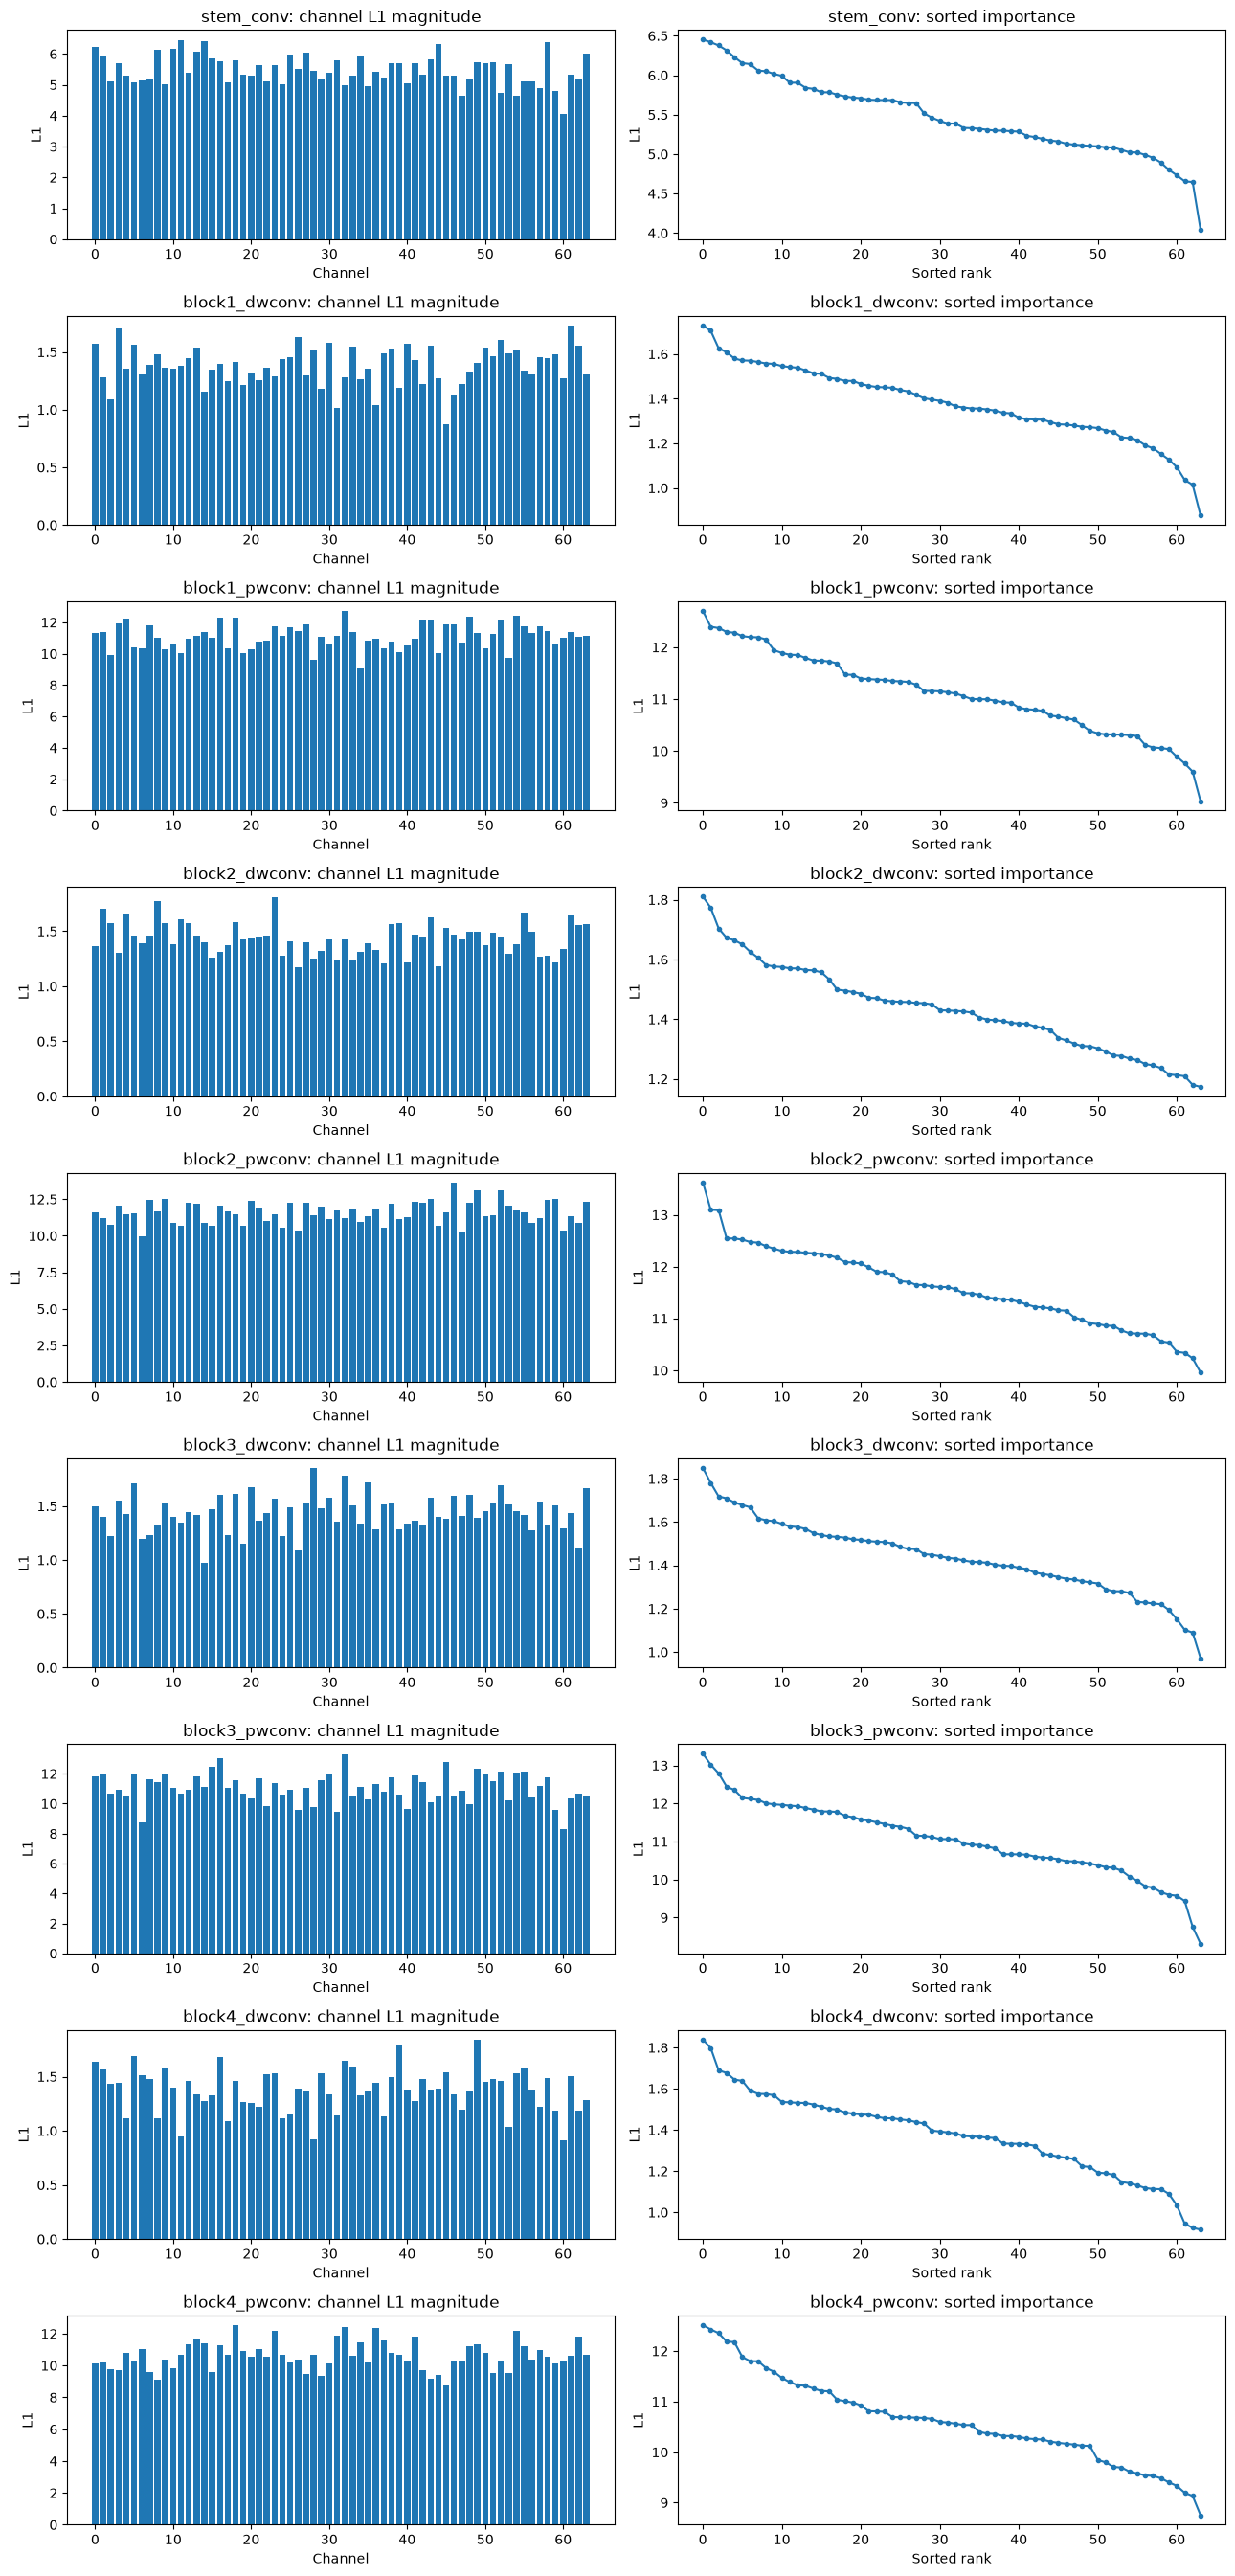

In [7]:
fig, axes = plt.subplots(len(importance), 2, figsize=(13, 3 * len(importance)), squeeze=False)
for row, (name, scores) in enumerate(importance.items()):
    axes[row, 0].bar(np.arange(len(scores['l1'])), scores['l1'])
    axes[row, 0].set_title(f'{name}: channel L1 magnitude')
    axes[row, 0].set_xlabel('Channel')
    axes[row, 0].set_ylabel('L1')
    axes[row, 1].plot(np.sort(scores['l1'])[::-1], marker='.')
    axes[row, 1].set_title(f'{name}: sorted importance')
    axes[row, 1].set_xlabel('Sorted rank')
    axes[row, 1].set_ylabel('L1')
plt.tight_layout()
plt.show()

## 6. Persistent masks and residual-safe stream masking

In [18]:
@keras.saving.register_keras_serializable(package='pruning')
class PersistentMaskedActivation(layers.Layer):
    def __init__(self, width, mask_values=None, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.width = int(width)
        self.mask_values = list(mask_values) if mask_values is not None else [1.0] * self.width
        self.activation_name = activation

    def build(self, input_shape):
        self.mask = self.add_weight(
            name='persistent_channel_mask', shape=(self.width,),
            initializer=keras.initializers.Constant(self.mask_values), trainable=False,
        )

    def call(self, inputs):
        outputs = tf.nn.relu(inputs) if self.activation_name == 'relu' else inputs
        return outputs * self.mask

    def get_config(self):
        config = super().get_config()
        config.update({'width': self.width, 'mask_values': self.mask_values, 'activation': self.activation_name})
        return config


@keras.saving.register_keras_serializable(package='pruning')
class PersistentMaskedAdd(layers.Layer):
    def __init__(self, width, mask_values=None, **kwargs):
        super().__init__(**kwargs)
        self.width = int(width)
        self.mask_values = list(mask_values) if mask_values is not None else [1.0] * self.width

    def build(self, input_shape):
        self.mask = self.add_weight(
            name='persistent_channel_mask', shape=(self.width,),
            initializer=keras.initializers.Constant(self.mask_values), trainable=False,
        )

    def call(self, inputs):
        return (inputs[0] + inputs[1]) * self.mask

    def get_config(self):
        config = super().get_config()
        config.update({'width': self.width, 'mask_values': self.mask_values})
        return config


class ArchitectureAdapter:
    """Interface between generic pruning logic and one model graph."""

    def __init__(self, source_model):
        self.model = source_model

    def channel_groups(self):
        raise NotImplementedError

    def sensitivity_mask_layers(self, group):
        raise NotImplementedError

    def persistent_mask_layers(self):
        raise NotImplementedError

    def build_masked_model(self, stream_mask, mask_layers):
        raise NotImplementedError


class DSCNNResidualAdapter(ArchitectureAdapter):
    """Adapter for training.model.build_dscnn_s residual DS-CNN graphs."""

    def __init__(self, source_model):
        super().__init__(source_model)
        self.stream_width = int(source_model.get_layer('stem_conv').filters)
        self._relu_layers = [layer.name for layer in source_model.layers
                             if isinstance(layer, layers.ReLU) and layer.output.shape[-1] == self.stream_width]
        self._add_layers = [layer.name for layer in source_model.layers
                            if isinstance(layer, layers.Add) and layer.output.shape[-1] == self.stream_width]
        if not self._relu_layers or not self._add_layers:
            raise ValueError('Model does not match the residual DS-CNN adapter contract.')
        for layer in source_model.layers:
            if isinstance(layer, layers.Add):
                shapes = [tuple(t.shape[-1:]) for t in layer.input]
                if len(shapes) != 2 or shapes[0] != shapes[1] or shapes[0][0] != self.stream_width:
                    raise ValueError(f'Residual dependency is not channel-compatible: {layer.name}')

    def channel_groups(self):
        groups = {}
        for layer in self.model.layers:
            if isinstance(layer, (layers.Conv2D, layers.DepthwiseConv2D)):
                weights = layer.get_weights()[0]
                if isinstance(layer, layers.DepthwiseConv2D):
                    l1 = np.sum(np.abs(weights), axis=(0, 1, 3))
                    l2 = np.sqrt(np.sum(weights ** 2, axis=(0, 1, 3)))
                else:
                    l1 = np.sum(np.abs(weights), axis=(0, 1, 2))
                    l2 = np.sqrt(np.sum(weights ** 2, axis=(0, 1, 2)))
                if len(l1) == self.stream_width or layer.name == 'stem_conv':
                    groups[layer.name] = {'l1': l1.astype(float), 'l2': l2.astype(float)}
        return groups

    def sensitivity_mask_layers(self, group):
        if group == 'stem_conv':
            return [name for name in self._relu_layers if name == 'stem_relu']
        block = group.split('_')[0]
        if group.endswith('_dwconv'):
            return [f'{block}_dw_relu']
        if group.endswith('_pwconv'):
            return [f'{block}_add']
        raise ValueError(f'No sensitivity boundary defined for {group}')

    def persistent_mask_layers(self):
        return self._relu_layers + self._add_layers

    def build_masked_model(self, stream_mask, mask_layers):
        mask_values = np.asarray(stream_mask, dtype=np.float32).tolist()
        mask_layers = set(mask_layers)

        def clone_fn(layer):
            if layer.name in mask_layers and isinstance(layer, layers.ReLU):
                return PersistentMaskedActivation(self.stream_width, mask_values, name=layer.name)
            if layer.name in mask_layers and isinstance(layer, layers.Add):
                return PersistentMaskedAdd(self.stream_width, mask_values, name=layer.name)
            return layer.__class__.from_config(layer.get_config())

        cloned = keras.models.clone_model(self.model, clone_function=clone_fn)
        for old, new in zip(self.model.layers, cloned.layers):
            if old.weights and not isinstance(new, (PersistentMaskedActivation, PersistentMaskedAdd)):
                new.set_weights(old.get_weights())
        return cloned


ADAPTER = DSCNNResidualAdapter(model)
CHANNEL_GROUPS = ADAPTER.channel_groups()
STREAM_WIDTH = ADAPTER.stream_width
STREAM_LAYERS = ADAPTER.persistent_mask_layers()
print(f'Adapter: {ADAPTER.__class__.__name__}')
print(f'Discovered convolution groups: {list(CHANNEL_GROUPS)}')
print(f'Stream width: {STREAM_WIDTH}')

Adapter: DSCNNResidualAdapter
Discovered convolution groups: ['stem_conv', 'block1_dwconv', 'block1_pwconv', 'block2_dwconv', 'block2_pwconv', 'block3_dwconv', 'block3_pwconv', 'block4_dwconv', 'block4_pwconv']
Stream width: 64


## 7. Sensitivity analysis

In [19]:
def stream_mask_for(channels):
    mask = np.ones(STREAM_WIDTH, dtype=np.float32)
    mask[np.asarray(channels, dtype=int)] = 0.0
    return mask

x_sens = x_val if SENSITIVITY_MAX_SAMPLES is None else x_val[:SENSITIVITY_MAX_SAMPLES]
y_sens = y_val if SENSITIVITY_MAX_SAMPLES is None else y_val[:SENSITIVITY_MAX_SAMPLES]
sensitivity_rows = []
for group, scores in CHANNEL_GROUPS.items():
    order = np.argsort(scores['l1'])
    mask_layers = ADAPTER.sensitivity_mask_layers(group)
    for ratio in SENSITIVITY_RATIOS:
        channels = order[:int(np.floor(len(order) * ratio))]
        candidate = ADAPTER.build_masked_model(stream_mask_for(channels), mask_layers)
        metrics = evaluate(candidate, x_sens, y_sens)
        sensitivity_rows.append({
            'layer': group,
            'mask_boundary': ', '.join(mask_layers),
            'ratio': ratio,
            'masked_channels': len(channels),
            'accuracy': metrics['accuracy'],
            'tpr': metrics['tpr'],
            'far': metrics['far'],
            'passes_subset_constraints': passes_constraints(metrics),
            'constraint_scope': f'first {len(x_sens):,} validation samples',
        })
sensitivity_df = pd.DataFrame(sensitivity_rows)
print(f'Sensitivity rows passing subset constraints: {int(sensitivity_df["passes_subset_constraints"].sum())}/{len(sensitivity_df)}')
display(sensitivity_df)

Sensitivity rows passing subset constraints: 39/72


,layer,mask_boundary,ratio,masked_channels,accuracy,tpr,far,passes_subset_constraints,constraint_scope
0,stem_conv,stem_relu,0.00,0,0.9745,0.841026,0.005540,True,"first 2,000 validation samples"
1,stem_conv,stem_relu,0.05,3,0.9740,0.851282,0.007756,True,"first 2,000 validation samples"
2,stem_conv,stem_relu,0.10,6,0.9740,0.830769,0.006094,True,"first 2,000 validation samples"
3,stem_conv,stem_relu,0.15,9,0.9730,0.825641,0.006648,True,"first 2,000 validation samples"
4,stem_conv,stem_relu,0.20,12,0.9740,0.846154,0.007202,True,"first 2,000 validation samples"
...,...,...,...,...,...,...,...,...,...
67,block4_pwconv,block4_add,0.15,9,0.9735,0.856410,0.008310,True,"first 2,000 validation samples"
68,block4_pwconv,block4_add,0.20,12,0.9745,0.856410,0.007202,True,"first 2,000 validation samples"
69,block4_pwconv,block4_add,0.30,19,0.9680,0.907692,0.021053,False,"first 2,000 validation samples"
70,block4_pwconv,block4_add,0.40,25,0.9670,0.733333,0.003878,True,"first 2,000 validation samples"


## 8. Sensitivity curves and candidate channels

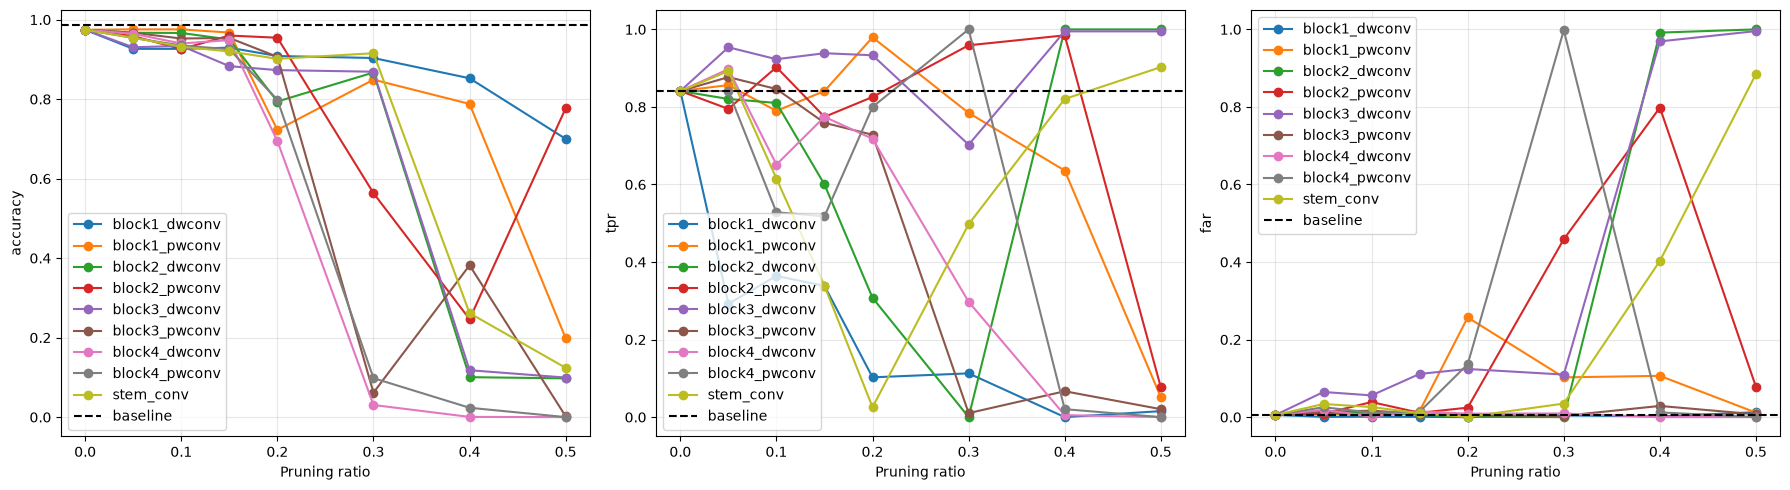

,layer,channel,l1,l2,rank_l1
109,block1_dwconv,45,0.877075,0.365070,64
95,block1_dwconv,31,1.014439,0.508770,63
100,block1_dwconv,36,1.035625,0.446729,62
66,block1_dwconv,2,1.092911,0.499951,61
110,block1_dwconv,46,1.126601,0.488655,60
...,...,...,...,...,...
32,stem_conv,32,4.989526,0.969945,57
24,stem_conv,24,5.021128,1.104218,56
9,stem_conv,9,5.023343,0.950769,55
40,stem_conv,40,5.053224,1.012451,54


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, frame in sensitivity_df.groupby('layer'):
    axes[0].plot(frame['ratio'], frame['accuracy'], marker='o', label=name)
    axes[1].plot(frame['ratio'], frame['tpr'], marker='o', label=name)
    axes[2].plot(frame['ratio'], frame['far'], marker='o', label=name)
for axis, metric in zip(axes, ['accuracy', 'tpr', 'far']):
    axis.axhline(baseline[metric], color='black', linestyle='--', label='baseline')
    axis.set_xlabel('Pruning ratio')
    axis.set_ylabel(metric)
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()

candidate_summary = importance_df.sort_values(['layer', 'l1']).groupby('layer').head(max(1, int(STREAM_WIDTH * AUTO_PRUNING_RATIO)))
display(candidate_summary)

## 9. Select and persist the final mask

In [20]:
normalized_scores = []
for scores in CHANNEL_GROUPS.values():
    values = scores['l1']
    normalized_scores.append(values / max(float(values.max()), 1e-12))
combined_scores = np.mean(np.stack(normalized_scores), axis=0)

if MANUAL_MASKS.get('stream'):
    candidate_specs = [('manual', sorted(set(int(v) for v in MANUAL_MASKS['stream'])))]
else:
    candidate_ratios = sorted(set([0.0, AUTO_PRUNING_RATIO] + [ratio for ratio in SENSITIVITY_RATIOS if ratio <= AUTO_PRUNING_RATIO]))
    candidate_specs = []
    for ratio in candidate_ratios:
        count = int(np.floor(STREAM_WIDTH * ratio))
        channels = np.argsort(combined_scores)[:count].astype(int).tolist()
        candidate_specs.append((ratio, channels))

candidate_rows = []
accepted_candidates = []
for label, channels in candidate_specs:
    candidate = ADAPTER.build_masked_model(stream_mask_for(channels), ADAPTER.persistent_mask_layers())
    metrics = evaluate(candidate)
    passes = passes_constraints(metrics)
    candidate_rows.append({'candidate': label, 'masked_channels': len(channels), 'accuracy': metrics['accuracy'], 'tpr': metrics['tpr'], 'far': metrics['far'], 'passes_constraints': passes})
    if passes:
        accepted_candidates.append((len(channels), channels, metrics))

candidate_search_df = pd.DataFrame(candidate_rows)
display(candidate_search_df)
if not accepted_candidates:
    raise RuntimeError('No candidate satisfies TPR >= 70% and FAR <= 1.0%. No masked model will be saved.')

_, selected_channels, final_candidate_metrics = max(accepted_candidates, key=lambda item: item[0])
final_mask = stream_mask_for(selected_channels)
print(f'Selected constraint-passing channels: {selected_channels}')
print(f'Effective pruning: {len(selected_channels)}/{STREAM_WIDTH} ({len(selected_channels) / STREAM_WIDTH:.1%})')
print(f"Selected TPR/FAR: {final_candidate_metrics['tpr']:.4f} / {final_candidate_metrics['far']:.4f}")

,candidate,masked_channels,accuracy,tpr,far,passes_constraints
0,0.00,0,0.987370,0.841026,0.006290,True
1,0.05,3,0.980921,0.815385,0.009025,True
2,0.10,6,0.985131,0.764103,0.006199,True
3,0.15,9,0.972411,0.707692,0.006473,True
4,0.20,12,0.975367,0.415385,0.003555,False


Selected constraint-passing channels: [60, 47, 6, 19, 17, 24, 2, 31, 26]
Effective pruning: 9/64 (14.1%)
Selected TPR/FAR: 0.7077 / 0.0065


## 10. Apply masks, evaluate, and save

In [21]:
if not passes_constraints(final_candidate_metrics):
    raise RuntimeError('Refusing to save a masked model that violates the TPR/FAR constraints.')

masked_model = ADAPTER.build_masked_model(final_mask, ADAPTER.persistent_mask_layers())
masked_metrics = evaluate(masked_model)
if not passes_constraints(masked_metrics):
    raise RuntimeError(f"Final masked model violates constraints: TPR={masked_metrics['tpr']:.4f}, FAR={masked_metrics['far']:.4f}")

print(f"Baseline accuracy: {baseline['accuracy']:.4f}")
print(f"Masked accuracy: {masked_metrics['accuracy']:.4f}")
print(f"Masked TPR/FAR: {masked_metrics['tpr']:.4f} / {masked_metrics['far']:.4f}")
print(f'Constraints passed: {passes_constraints(masked_metrics)}')
print(f'Input unchanged: {masked_model.input_shape == model.input_shape}')
print(f'Output unchanged: {masked_model.output_shape == model.output_shape}')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
masked_model.save(MASKED_MODEL_PATH)
reloaded_model = tf.keras.models.load_model(MASKED_MODEL_PATH, compile=False)
reloaded_metrics = evaluate(reloaded_model)
if not passes_constraints(reloaded_metrics):
    raise RuntimeError('Reloaded masked model does not satisfy the constraints.')

config = {
    'source_model': str(MODEL_PATH), 'masked_model': str(MASKED_MODEL_PATH), 'keyword': KEYWORD,
    'architecture_adapter': ADAPTER.__class__.__name__,
    'constraints': {'min_tpr': MIN_TPR, 'max_far': MAX_FAR},
    'auto_pruning_ratio': AUTO_PRUNING_RATIO, 'manual_masks': MANUAL_MASKS,
    'selected_channels': selected_channels, 'stream_width': STREAM_WIDTH,
    'persistent_mask_layers': STREAM_LAYERS, 'candidate_search': candidate_rows,
    'baseline_metrics': {k: v for k, v in baseline.items() if k != 'probabilities'},
    'masked_metrics': {k: v for k, v in masked_metrics.items() if k != 'probabilities'},
    'reloaded_metrics': {k: v for k, v in reloaded_metrics.items() if k != 'probabilities'},
}
PRUNING_CONFIG_PATH.write_text(json.dumps(config, indent=2))
print(f'Saved: {MASKED_MODEL_PATH}')
print(f'Saved: {PRUNING_CONFIG_PATH}')
print(f"Reload accuracy: {reloaded_metrics['accuracy']:.4f}")

Baseline accuracy: 0.9874
Masked accuracy: 0.9724
Masked TPR/FAR: 0.7077 / 0.0065
Constraints passed: True
Input unchanged: True
Output unchanged: True
Saved: /home/sanjeet/ai_workspace/KWS model/sih-2026/models/marvin_pruned_masked.keras
Saved: /home/sanjeet/ai_workspace/KWS model/sih-2026/results/marvin_pruning_config.json
Reload accuracy: 0.9724


## Notes

This notebook intentionally stops before fine-tuning and physical channel removal. Residual blocks share one 64-channel stream, so candidate channels are treated as stream channels rather than independently deleting depthwise or pointwise channels.

Sensitivity curves use `SENSITIVITY_MAX_SAMPLES` for faster exploration. Their 0% point is the unmasked model on that same subset; compare pruning deltas within each curve, and use the full baseline evaluation for the final comparison.

## 11. Final baseline versus masked comparison

This phase preserves the original architecture and tensor dimensions. Therefore, the masked `.keras` file is a persistent masked analysis artifact, not the final physically compact model. A real disk-size reduction will only be measured after channel removal and subsequent export. The table below reports the actual file sizes and the current quality metrics.

In [23]:
def file_size_bytes(path):
    return int(path.stat().st_size)

baseline_size_bytes = file_size_bytes(MODEL_PATH)
masked_size_bytes = file_size_bytes(MASKED_MODEL_PATH)
size_delta_bytes = masked_size_bytes - baseline_size_bytes
size_delta_percent = 100.0 * size_delta_bytes / baseline_size_bytes

comparison_rows = [
    {
        'Model': 'Baseline', 'Model file': MODEL_PATH.name,
        'Model size (KB)': baseline_size_bytes / 1024,
        'Accuracy (%)': baseline['accuracy'] * 100,
        'TPR (%)': baseline['tpr'] * 100, 'FAR/FPR (%)': baseline['far'] * 100,
        'False accepts': baseline['false_accepts'], 'Masked channels': 0,
        'Constraints passed': passes_constraints(baseline), 'Architecture changed': 'No',
    },
    {
        'Model': 'Masked', 'Model file': MASKED_MODEL_PATH.name,
        'Model size (KB)': masked_size_bytes / 1024,
        'Accuracy (%)': masked_metrics['accuracy'] * 100,
        'TPR (%)': masked_metrics['tpr'] * 100, 'FAR/FPR (%)': masked_metrics['far'] * 100,
        'False accepts': masked_metrics['false_accepts'], 'Masked channels': len(selected_channels),
        'Constraints passed': passes_constraints(masked_metrics), 'Architecture changed': 'No',
    },
]

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.style.format({
    'Model size (KB)': '{:.2f}', 'Accuracy (%)': '{:.2f}',
    'TPR (%)': '{:.2f}', 'FAR/FPR (%)': '{:.3f}',
}).hide(axis='index'))

print(f'Constraints: TPR >= {MIN_TPR:.0%}, FAR/FPR <= {MAX_FAR:.2%}')
print(f'Baseline model size: {baseline_size_bytes:,} bytes ({baseline_size_bytes / 1024:.2f} KB)')
print(f'Masked model size:   {masked_size_bytes:,} bytes ({masked_size_bytes / 1024:.2f} KB)')
print(f'Size change:         {size_delta_bytes:+,} bytes ({size_delta_percent:+.2f}%)')
print('Important: this masked size is not the final physically channel-pruned deployment size.')

config = json.loads(PRUNING_CONFIG_PATH.read_text())
config['model_sizes'] = {
    'baseline_bytes': baseline_size_bytes,
    'baseline_kb': baseline_size_bytes / 1024,
    'masked_bytes': masked_size_bytes,
    'masked_kb': masked_size_bytes / 1024,
    'delta_bytes': size_delta_bytes,
    'delta_percent': size_delta_percent,
    'note': 'Masked model preserves architecture; physical channel removal has not been performed.',
}
config['final_comparison_table'] = comparison_rows
PRUNING_CONFIG_PATH.write_text(json.dumps(config, indent=2))
print(f'Updated pruning configuration: {PRUNING_CONFIG_PATH}')

Model,Model file,Model size (KB),Accuracy (%),TPR (%),FAR/FPR (%),False accepts,Masked channels,Constraints passed,Architecture changed
Baseline,marvin.keras,425.05,98.74,84.10,0.629,69,0,True,No
Masked,marvin_pruned_masked.keras,240.67,97.24,70.77,0.647,71,9,True,No


Constraints: TPR >= 70%, FAR/FPR <= 1.00%
Baseline model size: 435,249 bytes (425.05 KB)
Masked model size:   246,443 bytes (240.67 KB)
Size change:         -188,806 bytes (-43.38%)
Important: this masked size is not the final physically channel-pruned deployment size.
Updated pruning configuration: /home/sanjeet/ai_workspace/KWS model/sih-2026/results/marvin_pruning_config.json


In [13]:
config = json.loads(PRUNING_CONFIG_PATH.read_text())
config['model_sizes'] = {
    'baseline_bytes': baseline_size_bytes,
    'baseline_kb': baseline_size_bytes / 1024,
    'masked_bytes': masked_size_bytes,
    'masked_kb': masked_size_bytes / 1024,
    'delta_bytes': size_delta_bytes,
    'delta_percent': size_delta_percent,
    'note': 'Masked model preserves architecture; physical channel removal has not been performed.',
}
config['final_comparison_table'] = comparison_rows
PRUNING_CONFIG_PATH.write_text(json.dumps(config, indent=2))
print(f'Updated pruning configuration: {PRUNING_CONFIG_PATH}')

Updated pruning configuration: /home/sanjeet/ai_workspace/KWS model/sih-2026/results/marvin_pruning_config.json
